# Analysis of H3

## Hypothesis 3
Shifts in feminist theoretical orientation within Heresies will coincide with changes in patterns of contribution, including the emergence of new contributors and changing thematic emphases associated with the magazine's rotating collectives.



### Sources
- Bar Plot in Matplotlib—GeeksforGeeks. (n.d.). Retrieved May 29, 2026, from https://www.geeksforgeeks.org/pandas/bar-plot-in-matplotlib/


### 1. Imports

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import re

### 2. Loading Dataset

In [27]:
df = pd.read_csv("/Users/sophiehamann/master-thesis-code/data/processed/07_h3_contributors.csv")
print(df.shape)
print(df["volume"].value_counts())

(2360, 5)
volume
Vol1_1977-1978    429
Vol4_1981-1983    404
Vol3_1980-1981    377
Vol5_1984-1985    363
Vol2_1978-1979    295
Vol6_1987-1989    257
Vol7_1990-1993    235
Name: count, dtype: int64


### 3. Helper functions

In [28]:
def get_issue_number(filepath):
    match = re.search(r"heresies_(\d+)_combined", filepath)
    return int(match.group(1)) if match else None

def get_volume(issue_nr):
    if issue_nr <= 4:    return "Vol1_1977-1978"
    elif issue_nr <= 8:  return "Vol2_1978-1979"
    elif issue_nr <= 12: return "Vol3_1980-1981"
    elif issue_nr <= 16: return "Vol4_1981-1983"
    elif issue_nr <= 20: return "Vol5_1984-1985"
    elif issue_nr <= 24: return "Vol6_1987-1989"
    elif issue_nr <= 27: return "Vol7_1990-1993"
    else: return None

vol_order = [
    "Vol1_1977-1978", "Vol2_1978-1979", "Vol3_1980-1981", "Vol4_1981-1983",
    "Vol5_1984-1985", "Vol6_1987-1989", "Vol7_1990-1993"
]

In [29]:
# CONTRIBUTOR FREQUENCY PER VOLUME
# volume_freq = df.groupby(["volume", "person"]).size().reset_index(name="count")
# print(volume_freq.head(20))

### 5. New Contributors per Volume and Issue

In [30]:
# find the first issue each contributor ever appeared in
first_appearance = df.groupby("person")["issue"].min().reset_index()
first_appearance.columns = ["person", "first_issue"]
first_appearance["first_volume"] = first_appearance["first_issue"].apply(get_volume)

# count new contributors per volume
new_per_volume = first_appearance["first_volume"].value_counts()
new_per_volume = new_per_volume.reindex([v for v in vol_order if v in new_per_volume.index])

print("New contributors per volume:")
print(new_per_volume)

# count new contributors per issue
new_per_issue = first_appearance["first_issue"].value_counts().sort_index()
print("\nNew contributors per issue:")
print(new_per_issue)

New contributors per volume:
first_volume
Vol1_1977-1978    346
Vol2_1978-1979    232
Vol3_1980-1981    248
Vol4_1981-1983    286
Vol5_1984-1985    252
Vol6_1987-1989    206
Vol7_1990-1993    183
Name: count, dtype: int64

New contributors per issue:
first_issue
1      62
2     100
3      88
4      96
5      84
6      49
7      34
8      65
9      29
10     93
11     60
12     66
13     95
14      8
15     98
16     85
17    123
18     45
19     32
20     52
21     61
22     62
23     50
24     33
25     53
26     41
27     89
Name: count, dtype: int64


#### 5.1 Graph 1: New Contributors per Volume

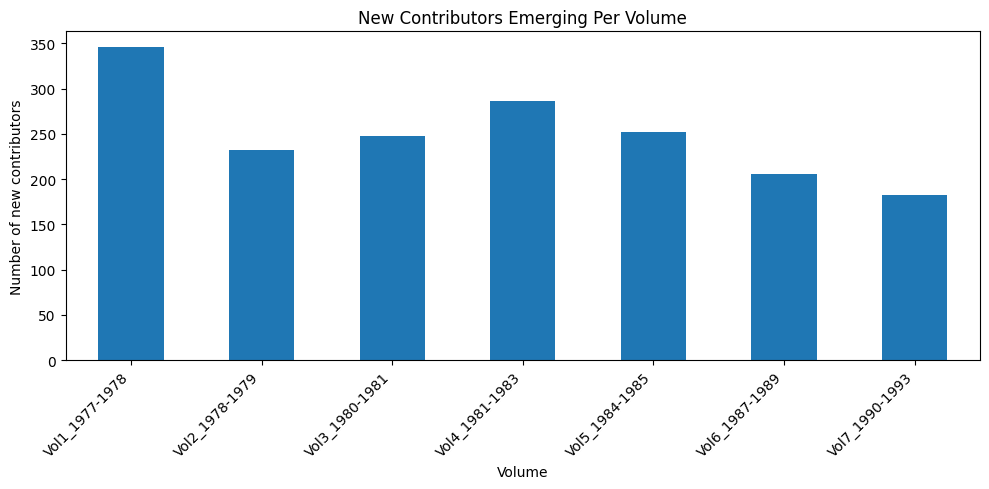

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))
new_per_volume.plot(kind="bar", ax=ax)
ax.set_xlabel("Volume")
ax.set_ylabel("Number of new contributors")
ax.set_title("New Contributors Emerging Per Volume")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_h3_new_contributors_volume.png")
plt.show()

#### 5.2 Graph 2: New Contributors per Issue

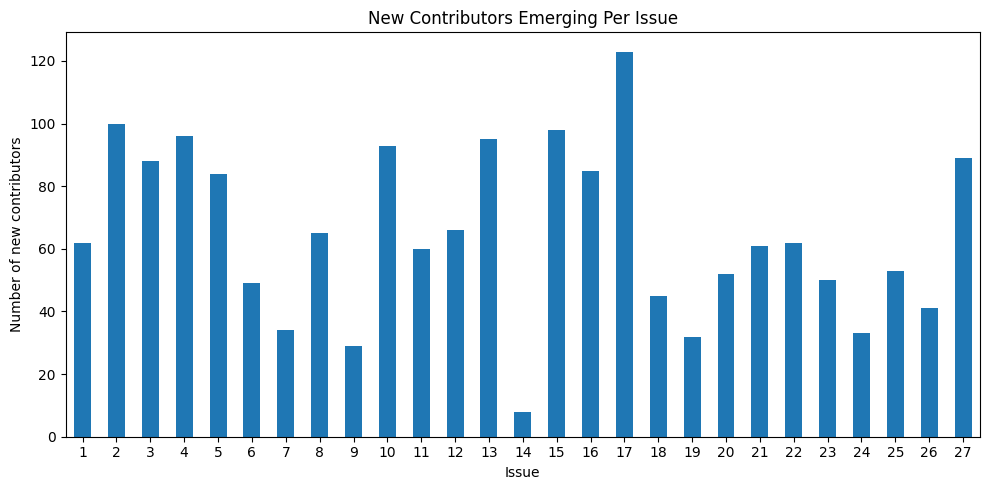

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))
new_per_issue.plot(kind="bar", ax=ax)
ax.set_xlabel("Issue")
ax.set_ylabel("Number of new contributors")
ax.set_title("New Contributors Emerging Per Issue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_h3_new_contributors_issue.png")
plt.show()

In [33]:
# # contributors UNIQUE TO ONE VOLUME
# volume_count = df.groupby("person")["volume"].nunique().reset_index()
# volume_count.columns = ["person", "volumes_active"]

# unique_contributors = volume_count[volume_count["volumes_active"] == 1]
# print(f"Contributors appearing in only one volume: {len(unique_contributors)}")

# unique_with_volume = unique_contributors.merge(first_appearance[["person", "first_volume"]], on="person")
# print(unique_with_volume["first_volume"].value_counts())

# # contributors who appear in only one issue
# issue_count = df.groupby("person")["issue"].nunique().reset_index()
# issue_count.columns = ["person", "issues_active"]

# unique_issue = issue_count[issue_count["issues_active"] == 1]
# print(f"\nContributors appearing in only one issue: {len(unique_issue)}")

# unique_with_issue = unique_issue.merge(first_appearance[["person", "first_issue"]], on="person")
# print(unique_with_issue["first_issue"].value_counts().sort_index())

The next 2 code cells have been written with AI. You can find the prompt here: AI_prompts/h3_help.txt

### Cross-reference test: new contributors per volume vs. theoretical keyword trends

In [34]:
# ── Cross-reference: new contributors per volume vs. theoretical keyword trends ──

import pandas as pd

# --- 1. Load the H2 lemmatized data and rebuild df_kw ---
# (copy of the logic from your H2 notebook cell 9)

df_raw = pd.read_csv("/Users/sophiehamann/master-thesis-code/data/processed/08_h2_lemmatized.csv")
df_raw["issue"]  = df_raw["source_file"].apply(get_issue_number)
df_raw["volume"] = df_raw["issue"].apply(get_volume)

vol_order  = ["Vol1_1977-1978", "Vol2_1978-1979", "Vol3_1980-1981",
              "Vol4_1981-1983", "Vol5_1984-1985", "Vol6_1987-1989", "Vol7_1990-1993"]
short_vols = ["Vol1", "Vol2", "Vol3", "Vol4", "Vol5", "Vol6", "Vol7"]

vol_totals = df_raw.groupby("volume").size()

foundational_keywords = ["woman", "women", "equality", "oppression", "consciousness", "experience", "sisterhood", "patriarchy"]
french_keywords       = ["body", "desire", "pleasure", "difference", "sexuality", "feminine", "essentialism"]
decon_keywords        = ["discourse", "power", "construction", "representation", "subjectivity", "identity", "deconstruction", "language"]
all_keywords          = foundational_keywords + french_keywords + decon_keywords

counts = {}
for kw in all_keywords:
    counts[kw] = {}
    for vol in vol_order:
        vol_texts = df_raw[df_raw["volume"] == vol]["text"].fillna("")
        hits = vol_texts.str.contains(r"\b" + kw + r"\b", case=False, regex=True).sum()
        counts[kw][vol] = round((hits / vol_totals[vol]) * 1000, 1)

df_kw = pd.DataFrame(counts).T
df_kw = df_kw[vol_order]

# --- 2. Average score per keyword group per volume ---
foundational_avg = df_kw.loc[foundational_keywords].mean()
french_avg       = df_kw.loc[french_keywords].mean()
decon_avg        = df_kw.loc[decon_keywords].mean()

# --- 3. Build summary table ---
summary = pd.DataFrame({
    "Volume":                     short_vols,
    "New contributors":           new_per_volume.reindex(vol_order).values,
    "Foundational vocab (avg)":   foundational_avg.values.round(2),
    "French feminist vocab (avg)": french_avg.values.round(2),
    "Deconstructionist vocab (avg)": decon_avg.values.round(2),
})

print(summary.to_string(index=False))

Volume  New contributors  Foundational vocab (avg)  French feminist vocab (avg)  Deconstructionist vocab (avg)
  Vol1               346                     15.11                         1.20                           0.99
  Vol2               232                     10.86                         1.31                           1.08
  Vol3               248                     12.89                         2.01                           0.36
  Vol4               286                     10.68                         0.74                           0.59
  Vol5               252                      5.82                         0.74                           0.38
  Vol6               206                      9.34                         1.63                           0.54
  Vol7               183                      6.71                         1.61                           2.18


### thematic vocabulary in top new contributors issue

In [35]:
# ── Thematic vocabulary in top new contributors' issues ──

import pandas as pd
import ast


# --- 1. Load the H1 corpus ---
df_h1 = pd.read_csv("/Users/sophiehamann/master-thesis-code/data/processed/06_h1_punctuation.csv")
df_h1["tokens"] = df_h1["tokens"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# add issue and volume columns (same as all your other notebooks)
df_h1["issue"]  = df_h1["source_file"].apply(get_issue_number)
df_h1["volume"] = df_h1["issue"].apply(get_volume)

# --- 2. Define keyword groups (same as H1/H2) ---
foundational      = {"women", "feminist", "female", "woman", "feminism", "sisterhood", "oppression", "patriarchy"}
french_feminist   = {"difference", "ecriture", "feminine", "jouissance", "irigaray", "kristeva", "cixous", "desire", "body"}
deconstructionist = {"discourse", "representation", "subjectivity", "gender", "identity", "deconstruction", "power", "construction"}

def keyword_score(token_list, keyword_set):
    """Count how many tokens from a row belong to a keyword group"""
    return sum(1 for t in token_list if t in keyword_set)

# --- 3. Find top 5 new contributors per volume ---
# (reuses first_appearance from cell 9 in your H3 notebook — run this after that cell)

vol_order = ["Vol1_1977-1978", "Vol2_1978-1979", "Vol3_1980-1981",
             "Vol4_1981-1983", "Vol5_1984-1985", "Vol6_1987-1989", "Vol7_1990-1993"]

results = []

for vol in vol_order:
    # get contributors who debuted in this volume
    new_in_vol = first_appearance[first_appearance["first_volume"] == vol]
    
    # find their total appearances and take the top 5 most active
    top5 = (df[df["person"].isin(new_in_vol["person"])]
            .groupby("person").size()
            .nlargest(5)
            .index.tolist())
    
    # get the issue numbers where these people appear
    their_issues = df[df["person"].isin(top5)]["issue"].unique()
    
    # filter H1 corpus to those issues
    h1_subset = df_h1[df_h1["issue"].isin(their_issues)].copy()
    
    # count keyword hits across all their issues
    total_tokens = h1_subset["tokens"].apply(len).sum()
    f_score  = h1_subset["tokens"].apply(lambda t: keyword_score(t, foundational)).sum()
    fr_score = h1_subset["tokens"].apply(lambda t: keyword_score(t, french_feminist)).sum()
    d_score  = h1_subset["tokens"].apply(lambda t: keyword_score(t, deconstructionist)).sum()
    
    results.append({
        "Volume":              vol,
        "Top 5 new contributors": ", ".join(top5),
        "Foundational (per 1k)":      round(f_score  / total_tokens * 1000, 2) if total_tokens else 0,
        "French feminist (per 1k)":   round(fr_score / total_tokens * 1000, 2) if total_tokens else 0,
        "Deconstructionist (per 1k)": round(d_score  / total_tokens * 1000, 2) if total_tokens else 0,
    })

summary = pd.DataFrame(results)
print(summary.to_string(index=False))

        Volume                                                              Top 5 new contributors  Foundational (per 1k)  French feminist (per 1k)  Deconstructionist (per 1k)
Vol1_1977-1978       Su Friedrich, JOAN BRADERMAN, Mary Beth Edelson, Lucy R. Lippard, Amy Sillman                  11.30                      0.82                        0.70
Vol2_1978-1979                Ana Mendieta, V. E. Browne, Vivian E. Browne, Anne Healy, Betye Saar                  10.05                      1.03                        0.94
Vol3_1980-1981           Lyn Hughes, Margaret Randall, hattie gossett, Clythia Fuller, Alesia Kunz                  10.48                      0.70                        0.29
Vol4_1981-1983            Diana Agosta, Lis Rhodes, Michele Godwin, Susan Kleckner, Cecilia Vicuña                   9.43                      0.52                        0.44
Vol5_1984-1985         Sondra Segal, Clarissa T. Sligh, P. Krupenye, Stephanie Skura, Beth Lapides                   6.7

### 13. Load Collective Membership Data
Note: there is a typo in the XML tag — "collective_strucutre" not "collective_structure"

In [36]:
df_corpus = pd.read_csv("/Users/sophiehamann/master-thesis-code/data/processed/01_parsed_corpus.csv")

df_collective = df_corpus[df_corpus["region_type"] == "collective_strucutre"].copy()

df_collective["issue"]  = df_collective["source_file"].apply(get_issue_number)
df_collective["volume"] = df_collective["issue"].apply(get_volume)

print(f"Collective rows: {len(df_collective)}")
print(df_collective[["issue", "text"]].head(10).to_string())

Collective rows: 156
      issue                                                                                    text
1         8  Editorial Collective: Lula Mae Blocton, Yvonne Flowers, Valerie Harris, Zarina Hashmi,
5         8       Heresies Collective - Ida Applebroog, Patsy Beckert, Joan Braderman, Su Friedrich
6         8                                                                                       E
7         8        This issue was typeset by Nancy Goldberg and Myrna Zimmerman, with headlines and
1136      9                                                                                 Issue 9
1137      9                                                       This issue was typeset by the The
1141      9                   HERESIES Collective: Ida Applebroog, Sue Heinemann, Elizabeth Hess, I
1142      9                                                                                    Sacr
2076      9                            The following people, have made MUCH NEE

### 13b. NER on Collective Structure Text

In [37]:
import spacy
import spacy_curated_transformers
from collections import Counter
from tqdm import tqdm

tqdm.pandas()
nlp = spacy.load("en_core_web_trf")

def extract_persons(text):
    if not isinstance(text, str):
        return []
    doc = nlp(text)
    return [ent.text.strip() for ent in doc.ents if ent.label_ == "PERSON"]

def clean_person(name):
    import re
    name = re.sub(r"^[^a-zA-ZÀ-ÿ]+", "", name)
    name = re.sub(r"[^a-zA-ZÀ-ÿ]+$", "", name).strip()
    if len(name.replace("-", " ").split()) < 2:
        return None
    if any(ch.isdigit() for ch in name):
        return None
    return name

df_collective["ner_persons"] = df_collective["text"].progress_apply(extract_persons)
df_collective["ner_persons"] = df_collective["ner_persons"].apply(
    lambda names: [n for n in (clean_person(n) for n in names) if n]
)

all_ner_names = [n for names in df_collective["ner_persons"] for n in names]
print(f"Total NER person mentions: {len(all_ner_names)}, Unique: {len(set(all_ner_names))}")
print("\nTop 20:")
for name, count in Counter(all_ner_names).most_common(20):
    print(f"  {name}: {count}")

100%|██████████| 156/156 [00:03<00:00, 40.80it/s]

Total NER person mentions: 209, Unique: 114

Top 20:
  Patsy Beckert: 16
  Ida Applebroog: 14
  Joan Braderman: 11
  Lyn Blumenthal: 8
  Sue Heinemann: 6
  Su Friedrich: 5
  Cynthia Carr: 5
  Mary Beth Edelson: 5
  Janet Froelich: 5
  Vivian E. Browne: 5
  Elaine Lustig Cohen: 4
  Ada Ciniglio: 4
  Elizabeth Hess: 3
  Sandra De Sando: 3
  Harmony Hammond: 3
  Avis Lang: 3
  Myrna Zimmerman: 2
  Joyce Kozloff: 2
  Pennelope Goodfriend: 2
  Janet Culbertson: 2


### 14. Extract Individual Names from Collective Text

In [38]:
collective_names = []

for _, row in df_collective.iterrows():
    for name in row["ner_persons"]:
        collective_names.append({
            "issue":  row["issue"],
            "volume": row["volume"],
            "name":   name
        })

df_coll_names = pd.DataFrame(collective_names)
print(f"Total collective name mentions: {len(df_coll_names)}")
print(df_coll_names["name"].value_counts().head(20))

Total collective name mentions: 209
name
Patsy Beckert           16
Ida Applebroog          14
Joan Braderman          11
Lyn Blumenthal           8
Sue Heinemann            6
Su Friedrich             5
Cynthia Carr             5
Mary Beth Edelson        5
Janet Froelich           5
Vivian E. Browne         5
Elaine Lustig Cohen      4
Ada Ciniglio             4
Elizabeth Hess           3
Sandra De Sando          3
Harmony Hammond          3
Avis Lang                3
Myrna Zimmerman          2
Joyce Kozloff            2
Pennelope Goodfriend     2
Janet Culbertson         2
Name: count, dtype: int64


#### 15. Collective Membership Size per Volume

Unique collective members per volume:
volume
Vol1_1977-1978    40
Vol2_1978-1979    25
Vol3_1980-1981    24
Vol4_1981-1983    26
Vol5_1984-1985    16
Vol6_1987-1989     5
Vol7_1990-1993    26
Name: name, dtype: int64


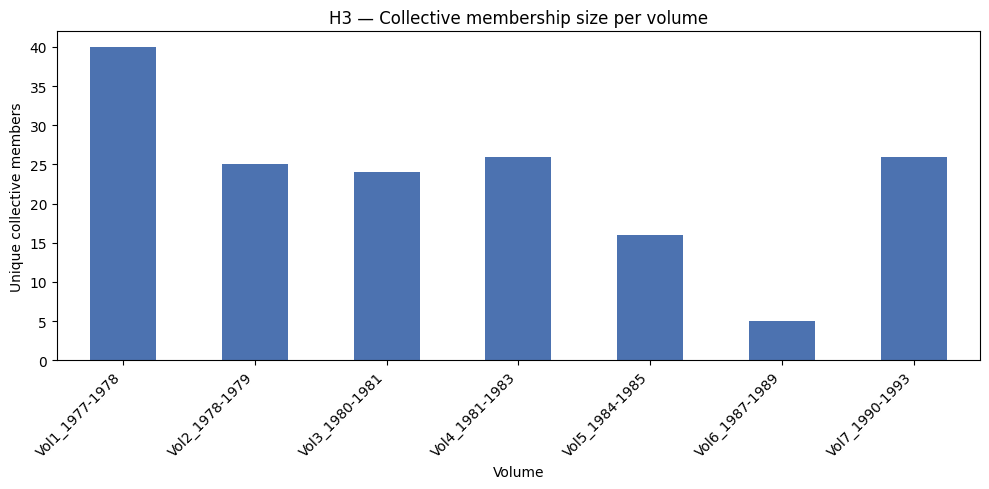

In [39]:
members_per_vol = df_coll_names.groupby("volume")["name"].nunique()
members_per_vol = members_per_vol.reindex([v for v in vol_order if v in members_per_vol.index])

print("Unique collective members per volume:")
print(members_per_vol)

fig, ax = plt.subplots(figsize=(10, 5))
members_per_vol.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_xlabel("Volume")
ax.set_ylabel("Unique collective members")
ax.set_title("H3 — Collective membership size per volume")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_h3_collective_size.png")
plt.show()

#### 16. New Collective Members per Volume

New collective members per volume:
first_volume
Vol1_1977-1978    40
Vol2_1978-1979    18
Vol3_1980-1981    18
Vol4_1981-1983    16
Vol5_1984-1985     6
Vol6_1987-1989     5
Vol7_1990-1993    11
Name: count, dtype: int64


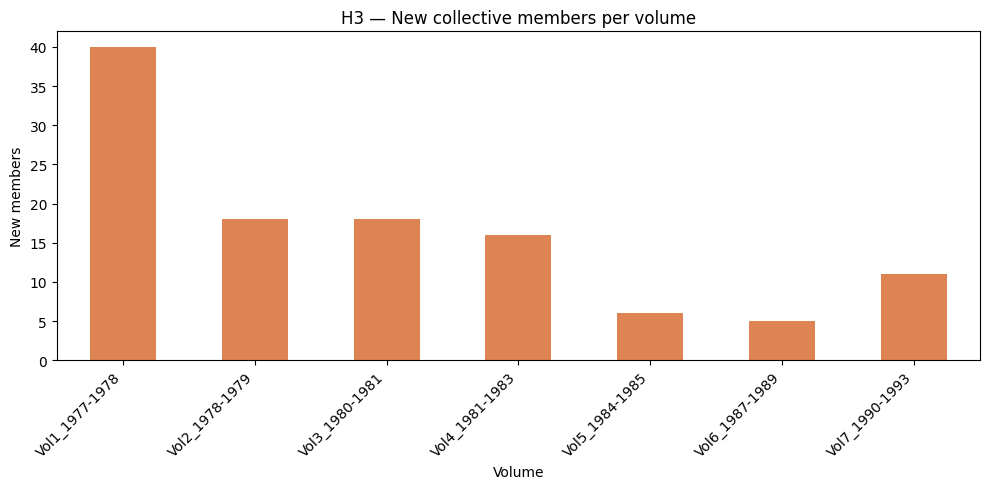

In [40]:
first_vol = df_coll_names.groupby("name")["issue"].min().reset_index()
first_vol["first_volume"] = first_vol["issue"].apply(get_volume)

new_members = first_vol["first_volume"].value_counts()
new_members = new_members.reindex([v for v in vol_order if v in new_members.index])

print("New collective members per volume:")
print(new_members)

fig, ax = plt.subplots(figsize=(10, 5))
new_members.plot(kind="bar", ax=ax, color="#DD8452")
ax.set_xlabel("Volume")
ax.set_ylabel("New members")
ax.set_title("H3 — New collective members per volume")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_h3_new_collective_members.png")
plt.show()

#### 17. Overlap Between Collective Members and Contributors

In [41]:
collective_set  = set(df_coll_names["name"].str.lower().str.strip())
contributor_set = set(df["person"].str.lower().str.strip())

overlap = collective_set & contributor_set

print(f"Collective members who also appear as contributors: {len(overlap)}")
print(f"Collective members only: {len(collective_set - contributor_set)}")
print(f"Contributors only: {len(contributor_set - collective_set)}")
print()
print("Overlapping names (sample):")
print(sorted(overlap)[:20])

Collective members who also appear as contributors: 46
Collective members only: 68
Contributors only: 1567

Overlapping names (sample):
['avis lang', 'carrie rickey', 'cynthia carr', 'denise green', 'diana agosta', 'edith becker', 'elizabeth hess', 'ellen lanyon', 'emma amos', 'estelle leontief', 'gail lineback', 'harmony hammond', 'ida applebroog', 'janet culbertson', 'joan braderman', 'josely carvalho', 'joyce kozloff', 'kathie brown', 'kay kenny', 'lenora champagne']


#### 18. Saving Results

In [42]:
volume_freq.to_csv("/Users/sophiehamann/master-thesis-code/data/processed/08_h3_volume_frequency.csv", index=False)
first_appearance.to_csv("/Users/sophiehamann/master-thesis-code/data/processed/08_h3_first_appearance.csv", index=False)
df_coll_names.to_csv("/Users/sophiehamann/master-thesis-code/data/processed/08_h3_collective_names.csv", index=False)